In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
from prophet import Prophet
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3, 'axes.facecolor': '#f5f5f5'})

In [13]:
df = pd.read_csv('final_ml_ready.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['product', 'date']).reset_index(drop=True)

FEATURE_COLS = [
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'roll_mean_3', 'roll_mean_6', 'roll_std_3',
    'trend_slope_12', 'quarter',
    'is_lebaran_window', 'is_year_end', 'year_index', 'fc_error_1', 'fc_acc_1', 'usd_change_rate'
]
TARGET = 'actual'

ARIMAX_EXOG_COLS = ['usd_change_rate', 'is_lebaran_window', 'is_year_end']

horizon_starts = pd.date_range('2025-03-01', '2025-10-01', freq='MS')
products = df['product'].unique()

print(f'Products: {list(products)}')
print(f'Horizons: {len(horizon_starts)} ({horizon_starts[0].date()} to {horizon_starts[-1].date()})')

Products: ['MU-250-40Kg', 'MU-302-50Kg', 'MU-380-40KG', 'MU-480-Combined']
Horizons: 8 (2025-03-01 to 2025-10-01)


In [14]:
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mp = mape(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mp}

def build_features(actual_series, forecast_series, known_row):
    n = len(actual_series)
    f = {}
    def _safe(v):
        return v if np.isfinite(v) else 0.0

    f['lag_1'] = _safe(actual_series[-1]) if n >= 1 else 0.0
    f['lag_2'] = _safe(actual_series[-2]) if n >= 2 else 0.0
    f['lag_3'] = _safe(actual_series[-3]) if n >= 3 else 0.0
    f['lag_6'] = _safe(actual_series[-6]) if n >= 6 else 0.0
    f['lag_12'] = _safe(actual_series[-12]) if n >= 12 else 0.0
    f['roll_mean_3'] = _safe(np.mean(actual_series[-3:])) if n >= 3 else 0.0
    f['roll_mean_6'] = _safe(np.mean(actual_series[-6:])) if n >= 6 else 0.0
    f['roll_std_3'] = _safe(np.std(actual_series[-3:])) if n >= 3 else 0.0
    f['trend_slope_12'] = _safe(np.polyfit(np.arange(12), actual_series[-12:], 1)[0]) if n >= 12 else 0.0
    if n >= 1:
        a, fc = actual_series[-1], forecast_series[-1]
        fc_err = (a - _safe(fc)) / a if a != 0 else 0
    else:
        fc_err = 0.0
    f['fc_error_1'] = fc_err
    f['fc_acc_1'] = 1 - abs(fc_err)
    for col in ['quarter', 'is_lebaran_window', 'is_year_end', 'year_index', 'usd_change_rate']:
        f[col] = _safe(known_row[col])
    return pd.Series(f)

In [15]:
def run_wfcv_sklearn(model_fn, prod_data, horizon_starts):
    prod_data = prod_data.sort_values('date').reset_index(drop=True)
    all_horizon_metrics = []

    for h_start in horizon_starts:
        cutoff = h_start - pd.DateOffset(months=1)
        train_df = prod_data[prod_data['date'] <= cutoff].copy()
        pred_dates = pd.date_range(h_start, periods=3, freq='MS')

        train_df = train_df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
        if len(train_df) < 10:
            all_horizon_metrics.append({'MAE': np.nan, 'MSE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan,
                                        'preds': [], 'actuals': [], 'dates': []})
            continue

        model = model_fn()
        model.fit(train_df[FEATURE_COLS], train_df[TARGET])

        actual_series = list(train_df[TARGET].values)
        forecast_series = list(train_df['forecast'].values)
        preds = []
        actuals = []

        for pdate in pred_dates:
            row = prod_data[prod_data['date'] == pdate]
            if len(row) == 0:
                preds.append(np.nan)
                continue
            row = row.iloc[0]
            feat = build_features(actual_series, forecast_series, row)
            X = feat[FEATURE_COLS].values.reshape(1, -1)
            pred = model.predict(X)[0]
            preds.append(pred)
            actuals.append(row[TARGET])
            actual_series.append(pred)
            forecast_series.append(row['forecast'])

        preds = np.array(preds)
        actuals = np.array(actuals)
        mask = ~np.isnan(preds)
        if mask.sum() < 2:
            all_horizon_metrics.append({'MAE': np.nan, 'MSE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan,
                                        'preds': [], 'actuals': [], 'dates': []})
        else:
            h_metrics = compute_metrics(actuals[mask], preds[mask])
            h_metrics['preds'] = list(preds[mask])
            h_metrics['actuals'] = list(actuals[mask])
            h_metrics['dates'] = [d for d, m in zip(pred_dates, mask) if m]
            all_horizon_metrics.append(h_metrics)

    avg = {k: np.nanmean([m[k] for m in all_horizon_metrics]) for k in ['MAE', 'MSE', 'RMSE', 'MAPE']}
    return {'per_horizon': all_horizon_metrics, 'avg': avg}

In [16]:
def run_wfcv_prophet(prod_data, horizon_starts):
    prod_data = prod_data.sort_values('date').reset_index(drop=True)
    all_horizon_metrics = []

    for h_start in horizon_starts:
        cutoff = h_start - pd.DateOffset(months=1)
        train_df = prod_data[prod_data['date'] <= cutoff].copy()
        pred_dates = pd.date_range(h_start, periods=3, freq='MS')

        train_df = train_df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
        if len(train_df) < 10:
            all_horizon_metrics.append({'MAE': np.nan, 'MSE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan,
                                        'preds': [], 'actuals': [], 'dates': []})
            continue

        prophet_df = train_df[['date', TARGET] + FEATURE_COLS].rename(columns={'date': 'ds', TARGET: 'y'})
        m = Prophet()
        for col in FEATURE_COLS:
            m.add_regressor(col)
        m.fit(prophet_df)

        actual_series = list(train_df[TARGET].values)
        forecast_series = list(train_df['forecast'].values)
        preds = []
        actuals = []

        for pdate in pred_dates:
            row = prod_data[prod_data['date'] == pdate]
            if len(row) == 0:
                preds.append(np.nan)
                continue
            row = row.iloc[0]
            feat = build_features(actual_series, forecast_series, row)
            future = pd.DataFrame({'ds': [pdate]})
            for col in FEATURE_COLS:
                future[col] = feat[col]
            forecast = m.predict(future)
            pred = forecast['yhat'].values[0]
            preds.append(pred)
            actuals.append(row[TARGET])
            actual_series.append(pred)
            forecast_series.append(row['forecast'])

        preds = np.array(preds)
        actuals = np.array(actuals)
        mask = ~np.isnan(preds)
        if mask.sum() < 2:
            all_horizon_metrics.append({'MAE': np.nan, 'MSE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan,
                                        'preds': [], 'actuals': [], 'dates': []})
        else:
            h_metrics = compute_metrics(actuals[mask], preds[mask])
            h_metrics['preds'] = list(preds[mask])
            h_metrics['actuals'] = list(actuals[mask])
            h_metrics['dates'] = [d for d, m in zip(pred_dates, mask) if m]
            all_horizon_metrics.append(h_metrics)

    avg = {k: np.nanmean([m[k] for m in all_horizon_metrics]) for k in ['MAE', 'MSE', 'RMSE', 'MAPE']}
    return {'per_horizon': all_horizon_metrics, 'avg': avg}

In [17]:
def run_wfcv_arimax(prod_data, horizon_starts):
    prod_data = prod_data.sort_values('date').reset_index(drop=True)
    all_horizon_metrics = []

    for h_start in horizon_starts:
        cutoff = h_start - pd.DateOffset(months=1)
        train_df = prod_data[prod_data['date'] <= cutoff].copy()
        pred_dates = pd.date_range(h_start, periods=3, freq='MS')

        train_df = train_df.dropna(subset=[TARGET] + ARIMAX_EXOG_COLS).reset_index(drop=True)
        if len(train_df) < 12:
            all_horizon_metrics.append({'MAE': np.nan, 'MSE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan,
                                        'preds': [], 'actuals': [], 'dates': []})
            continue

        y_train = train_df[TARGET].values
        exog_train = train_df[ARIMAX_EXOG_COLS].values

        model = auto_arima(
            y_train, exogenous=exog_train,
            seasonal=False,
            stepwise=True, trace=False,
            error_action='ignore', suppress_warnings=True,
            max_p=5, max_d=2, max_q=5
        )

        preds = []
        actuals = []

        for pdate in pred_dates:
            row = prod_data[prod_data['date'] == pdate]
            if len(row) == 0:
                preds.append(np.nan)
                continue
            row = row.iloc[0]
            exog_future = row[ARIMAX_EXOG_COLS].values.reshape(1, -1)
            pred = model.predict(n_periods=1, exogenous=exog_future)[0]
            preds.append(pred)
            actuals.append(row[TARGET])
            model.update(y=pred, exogenous=exog_future)

        preds = np.array(preds)
        actuals = np.array(actuals)
        mask = ~np.isnan(preds)
        if mask.sum() < 2:
            all_horizon_metrics.append({'MAE': np.nan, 'MSE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan,
                                        'preds': [], 'actuals': [], 'dates': []})
        else:
            h_metrics = compute_metrics(actuals[mask], preds[mask])
            h_metrics['preds'] = list(preds[mask])
            h_metrics['actuals'] = list(actuals[mask])
            h_metrics['dates'] = [d for d, m in zip(pred_dates, mask) if m]
            all_horizon_metrics.append(h_metrics)

    avg = {k: np.nanmean([m[k] for m in all_horizon_metrics]) for k in ['MAE', 'MSE', 'RMSE', 'MAPE']}
    return {'per_horizon': all_horizon_metrics, 'avg': avg}

In [18]:
models = {
    'RandomForest': lambda: RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=3, random_state=42, n_jobs=-1
    ),
    'XGBoost': lambda: xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42
    ),
    'Lasso': lambda: make_pipeline(
        StandardScaler(), Lasso(alpha=0.01, random_state=42, max_iter=10000)
    ),
    'LightGBM': lambda: lgb.LGBMRegressor(
        n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, verbose=-1
    ),
}

all_results = {}

for prod in products:
    print(f'\n========== {prod} ==========')
    prod_data = df[df['product'] == prod].copy()
    all_results[prod] = {}

    for name, fn in models.items():
        res = run_wfcv_sklearn(fn, prod_data, horizon_starts)
        all_results[prod][name] = res
        print(f'  {name:12s}  MAPE={res["avg"]["MAPE"]:7.2f}  MAE={res["avg"]["MAE"]:9.0f}  RMSE={res["avg"]["RMSE"]:9.0f}')

    res = run_wfcv_prophet(prod_data, horizon_starts)
    all_results[prod]['Prophet'] = res
    print(f'  {"Prophet":12s}  MAPE={res["avg"]["MAPE"]:7.2f}  MAE={res["avg"]["MAE"]:9.0f}  RMSE={res["avg"]["RMSE"]:9.0f}')

    res = run_wfcv_arimax(prod_data, horizon_starts)
    all_results[prod]['ARIMAX'] = res
    print(f'  {"ARIMAX":12s}  MAPE={res["avg"]["MAPE"]:7.2f}  MAE={res["avg"]["MAE"]:9.0f}  RMSE={res["avg"]["RMSE"]:9.0f}')


========== MU-250-40Kg ==========
  RandomForest  MAPE=  16.56  MAE=     5896  RMSE=     7180
  XGBoost       MAPE=  15.75  MAE=     5103  RMSE=     6954
  Lasso         MAPE=  21.45  MAE=     8588  RMSE=     9347
  LightGBM      MAPE=  22.25  MAE=     8125  RMSE=     9788


14:38:05 - cmdstanpy - INFO - Chain [1] start processing
14:38:05 - cmdstanpy - INFO - Chain [1] done processing
14:38:05 - cmdstanpy - INFO - Chain [1] start processing
14:38:06 - cmdstanpy - INFO - Chain [1] done processing
14:38:06 - cmdstanpy - INFO - Chain [1] start processing
14:38:06 - cmdstanpy - INFO - Chain [1] done processing
14:38:07 - cmdstanpy - INFO - Chain [1] start processing
14:38:07 - cmdstanpy - INFO - Chain [1] done processing
14:38:07 - cmdstanpy - INFO - Chain [1] start processing
14:38:07 - cmdstanpy - INFO - Chain [1] done processing
14:38:08 - cmdstanpy - INFO - Chain [1] start processing
14:38:08 - cmdstanpy - INFO - Chain [1] done processing
14:38:08 - cmdstanpy - INFO - Chain [1] start processing
14:38:09 - cmdstanpy - INFO - Chain [1] done processing
14:38:09 - cmdstanpy - INFO - Chain [1] start processing
14:38:09 - cmdstanpy - INFO - Chain [1] done processing


  Prophet       MAPE=  31.69  MAE=    13290  RMSE=    15055
  ARIMAX        MAPE=  25.13  MAE=    10913  RMSE=    11776

========== MU-302-50Kg ==========
  RandomForest  MAPE=  19.43  MAE=    52064  RMSE=    61515
  XGBoost       MAPE=  24.24  MAE=    69391  RMSE=    77576
  Lasso         MAPE=  31.89  MAE=    85411  RMSE=    96104
  LightGBM      MAPE=  29.84  MAE=    73368  RMSE=    81616


14:38:15 - cmdstanpy - INFO - Chain [1] start processing
14:38:16 - cmdstanpy - INFO - Chain [1] done processing
14:38:16 - cmdstanpy - INFO - Chain [1] start processing
14:38:16 - cmdstanpy - INFO - Chain [1] done processing
14:38:16 - cmdstanpy - INFO - Chain [1] start processing
14:38:17 - cmdstanpy - INFO - Chain [1] done processing
14:38:17 - cmdstanpy - INFO - Chain [1] start processing
14:38:17 - cmdstanpy - INFO - Chain [1] done processing
14:38:17 - cmdstanpy - INFO - Chain [1] start processing
14:38:18 - cmdstanpy - INFO - Chain [1] done processing
14:38:18 - cmdstanpy - INFO - Chain [1] start processing
14:38:18 - cmdstanpy - INFO - Chain [1] done processing
14:38:19 - cmdstanpy - INFO - Chain [1] start processing
14:38:19 - cmdstanpy - INFO - Chain [1] done processing
14:38:19 - cmdstanpy - INFO - Chain [1] start processing
14:38:19 - cmdstanpy - INFO - Chain [1] done processing


  Prophet       MAPE=  51.99  MAE=   130821  RMSE=   148976
  ARIMAX        MAPE=  22.44  MAE=    67554  RMSE=    74943

========== MU-380-40KG ==========
  RandomForest  MAPE=   9.54  MAE=    47319  RMSE=    53512
  XGBoost       MAPE=   9.86  MAE=    47739  RMSE=    55150
  Lasso         MAPE=  10.80  MAE=    55428  RMSE=    57999
  LightGBM      MAPE=  14.76  MAE=    68162  RMSE=    73075


14:38:25 - cmdstanpy - INFO - Chain [1] start processing
14:38:25 - cmdstanpy - INFO - Chain [1] done processing
14:38:26 - cmdstanpy - INFO - Chain [1] start processing
14:38:26 - cmdstanpy - INFO - Chain [1] done processing
14:38:26 - cmdstanpy - INFO - Chain [1] start processing
14:38:26 - cmdstanpy - INFO - Chain [1] done processing
14:38:27 - cmdstanpy - INFO - Chain [1] start processing
14:38:27 - cmdstanpy - INFO - Chain [1] done processing
14:38:27 - cmdstanpy - INFO - Chain [1] start processing
14:38:27 - cmdstanpy - INFO - Chain [1] done processing
14:38:28 - cmdstanpy - INFO - Chain [1] start processing
14:38:28 - cmdstanpy - INFO - Chain [1] done processing
14:38:28 - cmdstanpy - INFO - Chain [1] start processing
14:38:28 - cmdstanpy - INFO - Chain [1] done processing
14:38:29 - cmdstanpy - INFO - Chain [1] start processing
14:38:29 - cmdstanpy - INFO - Chain [1] done processing


  Prophet       MAPE=  11.60  MAE=    54613  RMSE=    64010
  ARIMAX        MAPE=  18.91  MAE=    96451  RMSE=   101435

========== MU-480-Combined ==========
  RandomForest  MAPE=   9.25  MAE=     2520  RMSE=     2938
  XGBoost       MAPE=   6.74  MAE=     1793  RMSE=     2123
  Lasso         MAPE=  12.89  MAE=     3325  RMSE=     3867
  LightGBM      MAPE=  16.37  MAE=     4326  RMSE=     4800


14:38:51 - cmdstanpy - INFO - Chain [1] start processing
14:38:52 - cmdstanpy - INFO - Chain [1] done processing
14:38:52 - cmdstanpy - INFO - Chain [1] start processing
14:38:52 - cmdstanpy - INFO - Chain [1] done processing
14:38:52 - cmdstanpy - INFO - Chain [1] start processing
14:38:53 - cmdstanpy - INFO - Chain [1] done processing
14:38:53 - cmdstanpy - INFO - Chain [1] start processing
14:38:53 - cmdstanpy - INFO - Chain [1] done processing
14:38:53 - cmdstanpy - INFO - Chain [1] start processing
14:38:54 - cmdstanpy - INFO - Chain [1] done processing
14:38:54 - cmdstanpy - INFO - Chain [1] start processing
14:38:54 - cmdstanpy - INFO - Chain [1] done processing
14:38:54 - cmdstanpy - INFO - Chain [1] start processing
14:38:54 - cmdstanpy - INFO - Chain [1] done processing
14:38:55 - cmdstanpy - INFO - Chain [1] start processing
14:38:55 - cmdstanpy - INFO - Chain [1] done processing


  Prophet       MAPE=  18.13  MAE=     4847  RMSE=     5589
  ARIMAX        MAPE=  20.45  MAE=     5611  RMSE=     6240


In [19]:
model_names = ['RandomForest', 'XGBoost', 'Lasso', 'LightGBM', 'Prophet', 'ARIMAX']
metrics_keys = ['MAE', 'MSE', 'RMSE', 'MAPE']

for prod in products:
    print(f'\n=== {prod} - Avg WFCV Metrics ({len(horizon_starts)} horizons x 3 months) ===')
    rows = []
    for m in model_names:
        r = all_results[prod][m]['avg']
        rows.append({'Model': m, **{k: f'{r[k]:.2f}' for k in metrics_keys}})
    print(pd.DataFrame(rows).set_index('Model').to_string())


=== MU-250-40Kg - Avg WFCV Metrics (8 horizons x 3 months) ===
                   MAE           MSE      RMSE   MAPE
Model                                                
RandomForest   5895.56   71925542.00   7180.34  16.56
XGBoost        5103.33   83646539.63   6953.54  15.75
Lasso          8587.70  104229530.94   9346.94  21.45
LightGBM       8124.63  131983778.02   9787.69  22.25
Prophet       13289.68  351937995.43  15054.81  31.69
ARIMAX        10913.25  182247489.42  11775.92  25.13

=== MU-302-50Kg - Avg WFCV Metrics (8 horizons x 3 months) ===
                    MAE             MSE       RMSE   MAPE
Model                                                    
RandomForest   52064.50   4077107770.74   61515.47  19.43
XGBoost        69390.72   6527652256.35   77576.47  24.24
Lasso          85410.78   9647461440.11   96103.89  31.89
LightGBM       73368.05   8148750009.51   81616.14  29.84
Prophet       130821.08  31230519741.52  148975.84  51.99
ARIMAX         67554.46   73756402

In [20]:
with pd.ExcelWriter('wfcv_avg_metrics_by_product.xlsx') as writer:
    model_order = ['RandomForest', 'XGBoost', 'Lasso', 'LightGBM', 'Prophet', 'ARIMAX']
    for prod in products:
        rows = []
        for m in model_order:
            r = all_results[prod][m]['avg']
            rows.append({'Model': m, 'MAPE': r['MAPE'], 'MAE': r['MAE'], 'MSE': r['MSE'], 'RMSE': r['RMSE']})
        df_out = pd.DataFrame(rows).set_index('Model')
        df_out.to_excel(writer, sheet_name=prod[:31])
        print(f'{prod}: {df_out.shape[0]} models x {df_out.shape[1]} metrics')
print('Saved wfcv_avg_metrics_by_product.xlsx')

MU-250-40Kg: 6 models x 4 metrics
MU-302-50Kg: 6 models x 4 metrics
MU-380-40KG: 6 models x 4 metrics
MU-480-Combined: 6 models x 4 metrics
Saved wfcv_avg_metrics_by_product.xlsx


In [21]:
print('=== OVERALL (averaged across all 4 products) ===')
overall = {m: {k: [] for k in metrics_keys} for m in model_names}
for prod in products:
    for m in model_names:
        for k in metrics_keys:
            overall[m][k].append(all_results[prod][m]['avg'][k])

rows = []
for m in model_names:
    row = {'Model': m}
    for k in metrics_keys:
        row[k] = f'{np.mean(overall[m][k]):.2f}'
    rows.append(row)
print(pd.DataFrame(rows).set_index('Model').to_string())

=== OVERALL (averaged across all 4 products) ===
                   MAE            MSE      RMSE   MAPE
Model                                                 
RandomForest  26949.73  1782492942.67  31286.58  13.70
XGBoost       31006.57  2422211170.05  35450.95  14.15
Lasso         38187.88  3382884788.35  41829.39  19.26
LightGBM      38495.33  3479768622.20  42319.63  20.80
Prophet       50892.71  9038656476.60  58407.37  28.35
ARIMAX        45132.46  4851202685.81  48598.45  21.73


In [22]:
n_horizons = len(horizon_starts)
prod = products[0]
print(f'=== {prod} - Per-Horizon MAPE ===')
data = {}
for m in model_names:
    data[m] = [h['MAPE'] for h in all_results[prod][m]['per_horizon']]
data['Horizon'] = [f'H{i+1}' for i in range(n_horizons)]
df_h = pd.DataFrame(data).set_index('Horizon')
print(df_h.round(2).to_string())

=== MU-250-40Kg - Per-Horizon MAPE ===
         RandomForest  XGBoost  Lasso  LightGBM  Prophet  ARIMAX
Horizon                                                         
H1              63.09    59.76  60.24     76.71    54.64   50.43
H2              15.71    25.48  11.80     31.33   104.70   45.06
H3               5.35     3.62   5.84      4.56    11.73   42.77
H4              11.13     3.36  14.57      5.85    11.11   10.17
H5               9.72    10.20  18.84     11.16    11.94    7.22
H6               9.57     8.57  27.62     16.92    14.05   12.89
H7               6.86     7.41  15.57     13.95    16.10   16.78
H8              11.08     7.59  17.16     17.48    29.26   15.72


In [23]:
n_horizons = len(horizon_starts)
plot_months = pd.date_range('2025-03-01', '2026-03-01', freq='MS')

for prod in products:
    plt.figure(figsize=(16, 6))

    actuals = df[df['product'] == prod].set_index('date').loc[plot_months, TARGET]
    plt.plot(actuals.index, actuals.values, 'k-', linewidth=2.5, label='Actual')

    best_model = min(model_names, key=lambda m: all_results[prod][m]['avg']['MAPE'])
    best_mape = all_results[prod][best_model]['avg']['MAPE']

    for i in range(n_horizons):
        h = all_results[prod][best_model]['per_horizon'][i]
        if len(h['preds']) >= 2:
            plt.plot(h['dates'], h['preds'],
                     color='red', alpha=0.15, linewidth=1, marker='.', markersize=5)

    pred_series = []
    for i, month in enumerate(plot_months):
        if i < n_horizons:
            h = all_results[prod][best_model]['per_horizon'][i]
            if len(h['preds']) > 0:
                pred_series.append(h['preds'][0])
            else:
                pred_series.append(np.nan)
        else:
            h = all_results[prod][best_model]['per_horizon'][-1]
            step = i - (n_horizons - 1)
            if len(h['preds']) > step:
                pred_series.append(h['preds'][step])
            else:
                pred_series.append(np.nan)

    plt.plot(plot_months, pred_series, 'r-', marker='o', linewidth=1.8,
             label=f"{best_model} (MAPE={best_mape:.1f}%)")

    plt.title(f'{prod} - Best Model: {best_model} vs Actual (WFCV)', fontsize=14, fontweight='bold')
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Actual Sales', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(fontsize=11)
    plt.tight_layout()
    fname = prod.replace(' ', '_').replace('-', '_') + '_wfcv_forecast.png'
    plt.savefig(fname, dpi=150)
    print(f'{prod}: best = {best_model} (MAPE={best_mape:.1f}%) | saved {fname}')
    plt.close()

MU-250-40Kg: best = XGBoost (MAPE=15.8%) | saved MU_250_40Kg_wfcv_forecast.png
MU-302-50Kg: best = RandomForest (MAPE=19.4%) | saved MU_302_50Kg_wfcv_forecast.png
MU-380-40KG: best = RandomForest (MAPE=9.5%) | saved MU_380_40KG_wfcv_forecast.png
MU-480-Combined: best = XGBoost (MAPE=6.7%) | saved MU_480_Combined_wfcv_forecast.png


In [24]:
n_horizons = len(horizon_starts)
with pd.ExcelWriter('wfcv_errors.xlsx') as writer:
    for metric in metrics_keys:
        rows = []
        for i in range(n_horizons):
            row = {'Horizon': f'H{i+1}'}
            for prod in products:
                for m in model_names:
                    col = f'{prod}|{m}'
                    row[col] = all_results[prod][m]['per_horizon'][i].get(metric, np.nan)
            rows.append(row)
        df_out = pd.DataFrame(rows).set_index('Horizon')
        df_out.to_excel(writer, sheet_name=metric)
        print(f'{metric} sheet: {df_out.shape[0]} horizons x {df_out.shape[1]} cols')
print('Saved wfcv_errors.xlsx')

MAE sheet: 8 horizons x 24 cols
MSE sheet: 8 horizons x 24 cols
RMSE sheet: 8 horizons x 24 cols
MAPE sheet: 8 horizons x 24 cols
Saved wfcv_errors.xlsx


In [25]:
model_names = ['RandomForest', 'XGBoost', 'Lasso', 'LightGBM', 'Prophet', 'ARIMAX']
n_horizons = len(horizon_starts)

with pd.ExcelWriter('wfcv_predictions.xlsx') as writer:
    for prod in products:
        rows = []
        for i in range(n_horizons):
            row = {'Horizon': f'H{i+1}'}
            ref = all_results[prod][model_names[0]]['per_horizon'][i]
            n_steps = len(ref['dates'])
            for s in range(3):
                if s < n_steps:
                    d = ref['dates'][s]
                    row[f'Step{s+1}_Date'] = d.strftime('%Y-%m') if hasattr(d, 'strftime') else str(d)[:7]
                    row[f'Actual_Step{s+1}'] = ref['actuals'][s]
                else:
                    row[f'Step{s+1}_Date'] = ''
                    row[f'Actual_Step{s+1}'] = np.nan
            for m in model_names:
                h = all_results[prod][m]['per_horizon'][i]
                n_preds = len(h['preds'])
                for s in range(3):
                    row[f'{m}_Step{s+1}'] = h['preds'][s] if s < n_preds else np.nan
            rows.append(row)
        df_out = pd.DataFrame(rows).set_index('Horizon')
        sheet_name = prod[:31]
        df_out.to_excel(writer, sheet_name=sheet_name)
        print(f'{sheet_name}: {df_out.shape[0]} horizons x {df_out.shape[1]} cols')
print('Saved wfcv_predictions.xlsx')

MU-250-40Kg: 8 horizons x 24 cols
MU-302-50Kg: 8 horizons x 24 cols
MU-380-40KG: 8 horizons x 24 cols
MU-480-Combined: 8 horizons x 24 cols
Saved wfcv_predictions.xlsx


In [26]:
best_models = {}
for prod in products:
    best_name = min(model_names, key=lambda m: all_results[prod][m]['avg']['MAPE'])
    best_models[prod] = best_name
    print(f"{prod:20s} -> best: {best_name:12s}  MAPE={all_results[prod][best_name]['avg']['MAPE']:.2f}")


MU-250-40Kg          -> best: XGBoost       MAPE=15.75
MU-302-50Kg          -> best: RandomForest  MAPE=19.43
MU-380-40KG          -> best: RandomForest  MAPE=9.54
MU-480-Combined      -> best: XGBoost       MAPE=6.74


In [27]:
import os
import json as _json
import joblib

H8_CUTOFF = pd.Timestamp('2025-10-01') - pd.DateOffset(months=1)
PRED_DATES = pd.date_range('2025-10-01', periods=3, freq='MS')

os.makedirs('saved_models', exist_ok=True)

model_type_map = {
    'RandomForest': 'sklearn', 'XGBoost': 'sklearn', 'Lasso': 'sklearn', 'LightGBM': 'sklearn',
    'Prophet': 'prophet', 'ARIMAX': 'arimax'
}

sklearn_constructors = {
    'RandomForest': lambda: RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=3, random_state=42, n_jobs=-1),
    'XGBoost': lambda: xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42),
    'Lasso': lambda: make_pipeline(StandardScaler(), Lasso(alpha=0.01, random_state=42, max_iter=10000)),
    'LightGBM': lambda: lgb.LGBMRegressor(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=42, verbose=-1),
}

meta = {}

for prod in products:
    best = best_models[prod]
    model_type = model_type_map[best]
    safe_name = prod.replace(' ', '_').replace('-', '_')

    print(f'\n=== {prod} -> {best} ({model_type}) ===')
    prod_data = df[df['product'] == prod].copy().sort_values('date').reset_index(drop=True)
    train_df = prod_data[prod_data['date'] <= H8_CUTOFF].copy()

    pred_vals = np.full(3, np.nan)
    actual_vals = np.full(3, np.nan)
    baseline_vals = np.full(3, np.nan)

    if model_type == 'sklearn':
        train_feat = train_df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
        if len(train_feat) < 10:
            print(f'  Skipped: only {len(train_feat)} rows')
            meta[prod] = {'best_model': best, 'type': model_type, 'safe_name': safe_name, 'mape': float('inf'), 'mae': float('inf'), 'rmse': float('inf')}
            continue
        model = sklearn_constructors[best]()
        model.fit(train_feat[FEATURE_COLS], train_feat[TARGET])

        actual_series = list(train_feat[TARGET].values)
        forecast_series = list(train_feat['forecast'].values)
        for i, pdate in enumerate(PRED_DATES):
            row = prod_data[prod_data['date'] == pdate]
            if len(row) == 0:
                continue
            row = row.iloc[0]
            feat = build_features(actual_series, forecast_series, row)
            X = feat[FEATURE_COLS].values.reshape(1, -1)
            pred = model.predict(X)[0]
            pred_vals[i] = pred
            actual_vals[i] = row[TARGET]
            baseline_vals[i] = row['forecast']
            actual_series.append(pred)
            forecast_series.append(row['forecast'])

    elif model_type == 'prophet':
        prophet_df = train_df[['date', TARGET] + FEATURE_COLS].rename(columns={'date': 'ds', TARGET: 'y'})
        prophet_df = prophet_df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
        if len(prophet_df) < 10:
            print(f'  Skipped: only {len(prophet_df)} rows')
            meta[prod] = {'best_model': best, 'type': model_type, 'safe_name': safe_name, 'mape': float('inf'), 'mae': float('inf'), 'rmse': float('inf')}
            continue
        model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in FEATURE_COLS:
            model.add_regressor(col)
        model.fit(prophet_df)

        actual_series = list(prophet_df['y'].values)
        forecast_series = list(train_df.loc[prophet_df.index, 'forecast'].values)
        for i, pdate in enumerate(PRED_DATES):
            row = prod_data[prod_data['date'] == pdate]
            if len(row) == 0:
                continue
            row = row.iloc[0]
            feat = build_features(actual_series, forecast_series, row)
            future = pd.DataFrame({'ds': [pdate]})
            for col in FEATURE_COLS:
                future[col] = feat[col]
            forecast = model.predict(future)
            pred = forecast['yhat'].values[0]
            pred_vals[i] = pred
            actual_vals[i] = row[TARGET]
            baseline_vals[i] = row['forecast']
            actual_series.append(pred)
            forecast_series.append(row['forecast'])

    elif model_type == 'arimax':
        train_ari = train_df.dropna(subset=[TARGET] + ARIMAX_EXOG_COLS).reset_index(drop=True)
        if len(train_ari) < 12:
            print(f'  Skipped: only {len(train_ari)} rows')
            meta[prod] = {'best_model': best, 'type': model_type, 'safe_name': safe_name, 'mape': float('inf'), 'mae': float('inf'), 'rmse': float('inf')}
            continue
        y_train = train_ari[TARGET].values
        exog_train = train_ari[ARIMAX_EXOG_COLS].values
        model = auto_arima(
            y_train, exogenous=exog_train,
            seasonal=False, stepwise=True, trace=False,
            error_action='ignore', suppress_warnings=True,
            max_p=5, max_d=2, max_q=5
        )

        for i, pdate in enumerate(PRED_DATES):
            row = prod_data[prod_data['date'] == pdate]
            if len(row) == 0:
                continue
            row = row.iloc[0]
            exog_future = row[ARIMAX_EXOG_COLS].values.reshape(1, -1)
            pred = model.predict(n_periods=1, exogenous=exog_future)[0]
            pred_vals[i] = pred
            actual_vals[i] = row[TARGET]
            baseline_vals[i] = row['forecast']
            model.update(y=pred, exogenous=exog_future)

    fname = f'saved_models/{safe_name}'
    joblib.dump(model, f'{fname}_model.pkl')
    np.save(f'{fname}_preds.npy', pred_vals)
    np.save(f'{fname}_actuals.npy', actual_vals)
    np.save(f'{fname}_baseline.npy', baseline_vals)

    valid = ~np.isnan(actual_vals) & (actual_vals != 0)
    if valid.sum() >= 2:
        mp = mape(actual_vals[valid], pred_vals[valid])
        ma = mean_absolute_error(actual_vals[valid], pred_vals[valid])
        mr = np.sqrt(mean_squared_error(actual_vals[valid], pred_vals[valid]))
    else:
        mp = ma = mr = float('inf')

    meta[prod] = {
        'best_model': best, 'type': model_type, 'safe_name': safe_name,
        'mape': mp, 'mae': ma, 'rmse': mr,
    }
    print(f'  MAPE: {mp:.2f}  MAE: {ma:,.0f}  RMSE: {mr:,.0f}')

with open('saved_models/model_meta.json', 'w') as f:
    _json.dump(meta, f, indent=2)
print('\nAll models saved to saved_models/')



=== MU-250-40Kg -> XGBoost (sklearn) ===
  MAPE: 7.59  MAE: 4,413  RMSE: 4,977

=== MU-302-50Kg -> RandomForest (sklearn) ===
  MAPE: 19.03  MAE: 80,066  RMSE: 93,100

=== MU-380-40KG -> RandomForest (sklearn) ===
  MAPE: 12.10  MAE: 68,437  RMSE: 71,743

=== MU-480-Combined -> XGBoost (sklearn) ===
  MAPE: 9.15  MAE: 2,931  RMSE: 3,433

All models saved to saved_models/


In [28]:
print('=== Saved Model Summary (H8: Oct-Dec 2025) ===')
summary_rows = []
for prod in products:
    m = meta[prod]
    summary_rows.append({
        'Product': prod,
        'Best Model': m['best_model'],
        'Type': m['type'],
        'MAPE (%)': f"{m['mape']:.2f}" if m['mape'] != float('inf') else 'N/A',
        'MAE': f"{m['mae']:,.0f}" if m['mae'] != float('inf') else 'N/A',
        'RMSE': f"{m['rmse']:,.0f}" if m['rmse'] != float('inf') else 'N/A',
    })
print(pd.DataFrame(summary_rows).to_string(index=False))


=== Saved Model Summary (H8: Oct-Dec 2025) ===
        Product   Best Model    Type MAPE (%)    MAE   RMSE
    MU-250-40Kg      XGBoost sklearn     7.59  4,413  4,977
    MU-302-50Kg RandomForest sklearn    19.03 80,066 93,100
    MU-380-40KG RandomForest sklearn    12.10 68,437 71,743
MU-480-Combined      XGBoost sklearn     9.15  2,931  3,433


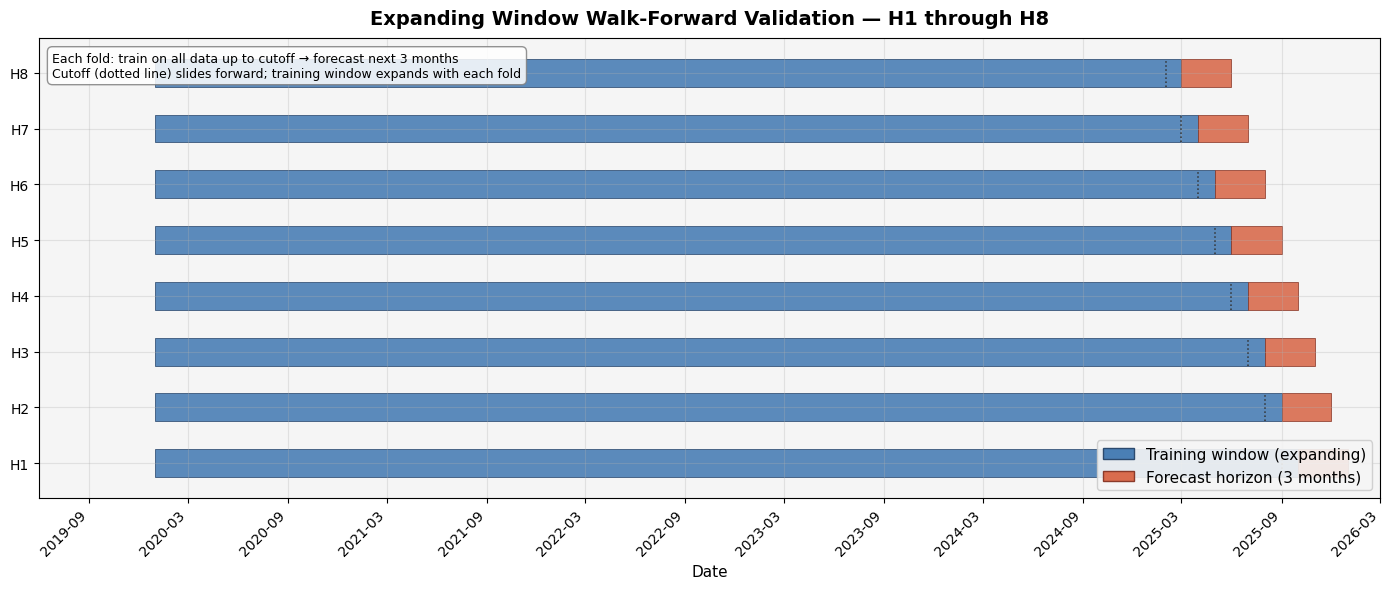

Saved expanding_window_scheme.png


In [29]:
from matplotlib.patches import Patch

DATA_START = pd.Timestamp('2020-01-01')
h_starts = pd.date_range('2025-03-01', periods=8, freq='MS')
n = len(h_starts)

fig, ax = plt.subplots(figsize=(14, 6))

BAR_H = 0.5

for i, h_start in enumerate(h_starts):
    cutoff = h_start - pd.DateOffset(months=1)
    pred_end = h_start + pd.DateOffset(months=3)
    y = n - 1 - i

    ax.barh(y, h_start - DATA_START, left=DATA_START, height=BAR_H,
            color='#4A7FB5', edgecolor='#2C4A6E', linewidth=0.6, alpha=0.9)

    ax.barh(y, pred_end - h_start, left=h_start, height=BAR_H,
            color='#D96C4E', edgecolor='#8B3A2A', linewidth=0.6, alpha=0.9)

    ax.plot([cutoff, cutoff], [y - BAR_H/2, y + BAR_H/2],
            color='#333333', linestyle=':', linewidth=1.1, zorder=5)

ax.set_yticks(range(n))
ax.set_yticklabels([f'H{i+1}' for i in range(n)])
ax.set_xlabel('Date', fontsize=11)
ax.set_title('Expanding Window Walk-Forward Validation — H1 through H8',
             fontsize=14, fontweight='bold', pad=10)

ax.set_xlim(pd.Timestamp('2019-06-01'), pd.Timestamp('2026-03-01'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

legend = ax.legend(
    handles=[
        Patch(facecolor='#4A7FB5', edgecolor='#2C4A6E', label='Training window (expanding)'),
        Patch(facecolor='#D96C4E', edgecolor='#8B3A2A', label='Forecast horizon (3 months)'),
    ],
    fontsize=11, loc='lower right', framealpha=0.9
)

ax.annotate(
    'Each fold: train on all data up to cutoff → forecast next 3 months\n'
    'Cutoff (dotted line) slides forward; training window expands with each fold',
    xy=(0.01, 0.97), xycoords='axes fraction', fontsize=9,
    va='top', ha='left',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.85)
)

plt.tight_layout()
plt.savefig('expanding_window_scheme.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved expanding_window_scheme.png')

In [30]:
# ── Safety Stock Calculation ──

import pandas as pd, numpy as np

df = pd.read_csv('final_ml_ready.csv', parse_dates=['date'])
products = sorted(df['product'].unique())
PRED_START = pd.Timestamp('2025-10-01')

LEAD_TIME = 1/30  # 1 day in months
SERVICE_LEVELS = {0.90: 1.28, 0.95: 1.65, 0.99: 2.33}

rows = []
for p in products:
    hist = df[df['product'] == p].dropna(subset=['actual']).copy()
    hist = hist[hist['date'] < PRED_START]

    mu = hist['actual'].mean()
    sigma = hist['actual'].std()
    cv = sigma / mu if mu > 0 else 0

    row = {'Product': p, 'Mean Demand': f"{mu:,.0f}",
           'Std Dev': f"{sigma:,.0f}", 'CV': f"{cv:.2f}",
           'Data Points': len(hist)}

    for sl, z in SERVICE_LEVELS.items():
        ss = z * sigma * np.sqrt(LEAD_TIME)
        row[f'SS (SL={sl:.0%})'] = f"{ss:,.0f}"

    rows.append(row)

df_out = pd.DataFrame(rows)
print('\n' + '='*100)
print('SAFETY STOCK BY PRODUCT (Lead Time = 1 day)')
print('='*100)
print(df_out.to_string(index=False))

df_out.to_excel('safety_stock.xlsx', index=False)
print('\nSaved safety_stock.xlsx')


SAFETY STOCK BY PRODUCT (Lead Time = 1 day)
        Product Mean Demand Std Dev   CV  Data Points SS (SL=90%) SS (SL=95%) SS (SL=99%)
    MU-250-40Kg     180,047 343,088 1.91           57      80,178     103,354     145,949
    MU-302-50Kg     243,125 133,540 0.55           57      31,208      40,228      56,807
    MU-380-40KG     420,421 111,059 0.26           57      25,954      33,456      47,244
MU-480-Combined      19,466   8,903 0.46           57       2,081       2,682       3,788

Saved safety_stock.xlsx
